Mounted at /content/drive
✅ Dataset extracted successfully!
✅ Using dataset path: /content/fruits
✅ Classes found: ['fresh_apple', 'fresh_banana', 'fresh_bitter_gourd', 'fresh_capsicum', 'fresh_orange', 'fresh_tomato', 'stale_apple', 'stale_banana', 'stale_bitter_gourd', 'stale_capsicum', 'stale_orange', 'stale_tomato']
✅ Train images: 11745 | Test images: 2937


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:02<00:00, 164MB/s]
<ipython-input-1-d533eaf2745a>:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Mixed precision training
<ipython-input-1-d533eaf2745a>:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



🚀 Training Started...

Epoch [1/20] - Loss: 0.2178, Accuracy: 92.86%
Epoch [2/20] - Loss: 0.1111, Accuracy: 96.38%
Epoch [3/20] - Loss: 0.0920, Accuracy: 96.97%
Epoch [4/20] - Loss: 0.0237, Accuracy: 99.21%
Epoch [5/20] - Loss: 0.0309, Accuracy: 98.99%
Epoch [6/20] - Loss: 0.0343, Accuracy: 98.88%
Epoch [7/20] - Loss: 0.0111, Accuracy: 99.62%
Epoch [8/20] - Loss: 0.0123, Accuracy: 99.55%
Epoch [9/20] - Loss: 0.0077, Accuracy: 99.73%
Epoch [10/20] - Loss: 0.0073, Accuracy: 99.77%
Epoch [11/20] - Loss: 0.0040, Accuracy: 99.87%
Epoch [12/20] - Loss: 0.0031, Accuracy: 99.91%
Epoch [13/20] - Loss: 0.0030, Accuracy: 99.88%
Epoch [14/20] - Loss: 0.0025, Accuracy: 99.92%
Epoch [15/20] - Loss: 0.0022, Accuracy: 99.91%
Epoch [16/20] - Loss: 0.0020, Accuracy: 99.93%
Epoch [17/20] - Loss: 0.0013, Accuracy: 99.97%
Epoch [18/20] - Loss: 0.0017, Accuracy: 99.95%
Epoch [19/20] - Loss: 0.0013, Accuracy: 99.95%
Epoch [20/20] - Loss: 0.0016, Accuracy: 99.97%

🎉 Training Complete!
✅ Model saved at /conte

Saving capcusm.jpg to capcusm.jpg


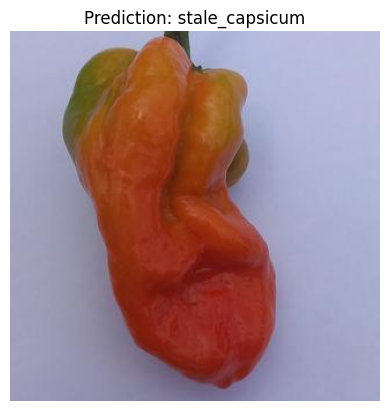

🍏 Predicted Label: stale_capsicum


In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision.models.vision_transformer import vit_b_16
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive, files  # Import Drive to access dataset

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')  # Mount Google Drive
drive_path = '/content/drive/MyDrive/archive.zip'  # Update with your Drive dataset path
dataset_root = '/content/fruits'  # Extracted dataset folder path

# 2️⃣ Extract Dataset
if not os.path.exists(dataset_root):  # Extract dataset only if not already done
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_root)
    print("✅ Dataset extracted successfully!")

# Ensure correct dataset path
subfolders = [f.name for f in os.scandir(dataset_root) if f.is_dir()]
dataset_path = os.path.join(dataset_root, subfolders[0]) if len(subfolders) == 1 else dataset_root

print("✅ Using dataset path:", dataset_path)

# 3️⃣ Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 4️⃣ Load Dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("✅ Classes found:", dataset.classes)
print("✅ Train images:", len(train_dataset), "| Test images:", len(test_dataset))

# 5️⃣ Define Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)  # Dynamically determine the number of classes

model = vit_b_16(weights="IMAGENET1K_V1")
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model = model.to(device)

# 6️⃣ Define Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
scaler = GradScaler()  # Mixed precision training

# 7️⃣ Train Model
num_epochs = 20
print("\n🚀 Training Started...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("\n🎉 Training Complete!")

# 8️⃣ Save Model
model_path = "/content/fruit_freshness_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")

# 9️⃣ Evaluate Model
model.eval()
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"\n📊 Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.2f}%")

# 🔟 Predict Fresh or Stale for a Single Image
def predict_fruit_freshness():
    print("📂 Upload an image for prediction:")
    uploaded = files.upload()

    if uploaded:
        for image_name in uploaded.keys():
            image_path = image_name
            image = Image.open(image_path).convert("RGB")
            transformed_image = transform(image).unsqueeze(0).to(device)

            # Make prediction
            with torch.no_grad():
                output = model(transformed_image)
                _, predicted_class = torch.max(output, 1)

            class_names = dataset.classes
            predicted_label = class_names[predicted_class.item()]

            # Display image
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"Prediction: {predicted_label}")
            plt.show()

            print(f"🍏 Predicted Label: {predicted_label}")

# 🔹 Call Prediction Function
predict_fruit_freshness()


📂 Upload an image for prediction:


Saving capcusm.jpg to capcusm.jpg


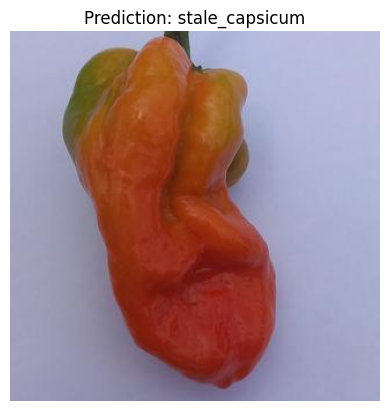

🍏 Predicted Label: stale_capsicum


In [ ]:
# 🔟 Predict Fresh or Stale for a Single Image
def predict_fruit_freshness():
    print("📂 Upload an image for prediction:")
    uploaded = files.upload()

    if uploaded:
        for image_name in uploaded.keys():
            image_path = image_name
            image = Image.open(image_path).convert("RGB")
            transformed_image = transform(image).unsqueeze(0).to(device)

            # Make prediction
            with torch.no_grad():
                output = model(transformed_image)
                _, predicted_class = torch.max(output, 1)

            class_names = dataset.classes
            predicted_label = class_names[predicted_class.item()]

            # Display image
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"Prediction: {predicted_label}")
            plt.show()

            print(f"🍏 Predicted Label: {predicted_label}")

# 🔹 Call Prediction Function
predict_fruit_freshness()

In [ ]:
import torch
from google.colab import files

# Save full model (architecture + weights)
save_path = "/content/vit_only_fruit_freshness.pt"
torch.save(model, save_path)

# Download to local machine
files.download(save_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>